In [7]:
# Train Baseline and Enhanced Models
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Decision Tree (depth=8)': DecisionTreeClassifier(random_state=42, max_depth=8),
}

# Heart Dataset Results
print("="*60)
print("HEART DISEASE DATASET - BASELINE & ENHANCED MODELS")
print("="*60)

heart_results = {}
for name, model in models.items():
    model.fit(X_train_h, y_train_h)
    y_pred = model.predict(X_test_h)
    
    acc = accuracy_score(y_test_h, y_pred)
    prec = precision_score(y_test_h, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_h, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_h, y_pred, average='weighted', zero_division=0)
    
    heart_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Diabetes Dataset Results
print("\n" + "="*60)
print("DIABETES DATASET - BASELINE & ENHANCED MODELS")
print("="*60)

diabetes_results = {}
for name, model in models.items():
    model.fit(X_train_d, y_train_d)
    y_pred = model.predict(X_test_d)
    
    acc = accuracy_score(y_test_d, y_pred)
    prec = precision_score(y_test_d, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_d, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_d, y_pred, average='weighted', zero_division=0)
    
    diabetes_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

HEART DISEASE DATASET - BASELINE & ENHANCED MODELS

Logistic Regression:
  Accuracy:  0.3770
  Precision: 0.3517
  Recall:    0.3770
  F1-Score:  0.3566

Decision Tree:
  Accuracy:  0.6557
  Precision: 0.5798
  Recall:    0.6557
  F1-Score:  0.6011

Decision Tree (depth=8):
  Accuracy:  0.8197
  Precision: 0.7852
  Recall:    0.8197
  F1-Score:  0.7923

DIABETES DATASET - BASELINE & ENHANCED MODELS

Logistic Regression:
  Accuracy:  0.1299
  Precision: 0.0481
  Recall:    0.1299
  F1-Score:  0.0702

Decision Tree:
  Accuracy:  0.1429
  Precision: 0.1335
  Recall:    0.1429
  F1-Score:  0.1349

Decision Tree (depth=8):
  Accuracy:  0.1883
  Precision: 0.1679
  Recall:    0.1883
  F1-Score:  0.1738


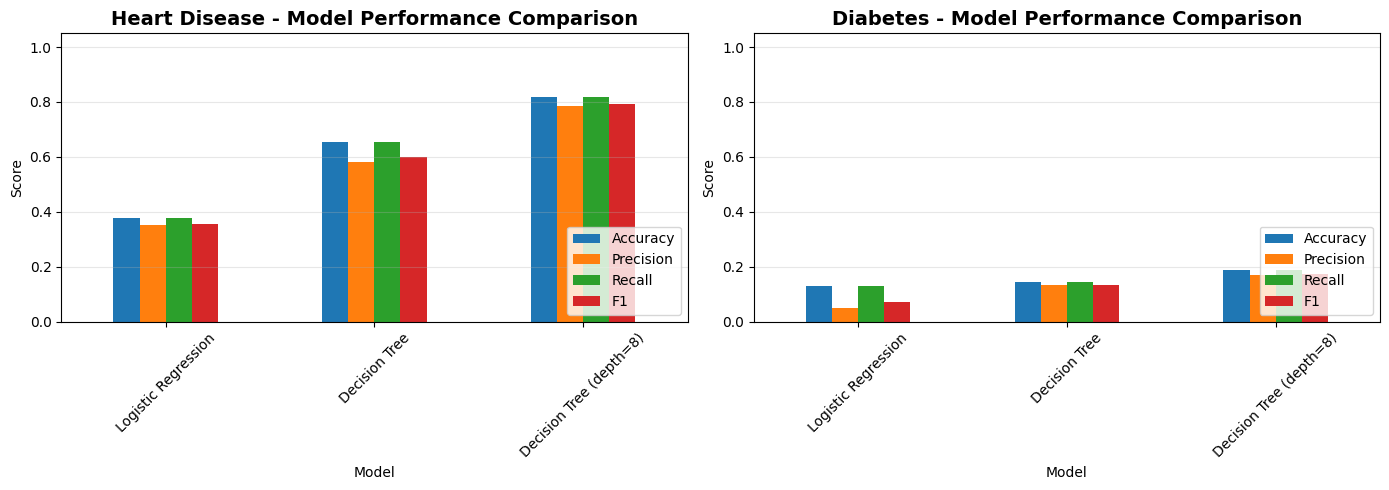

Model comparison charts generated!


In [8]:
# Visualize Model Performance Comparison
import matplotlib.pyplot as plt
import pandas as pd

# Create comparison DataFrames
heart_df_results = pd.DataFrame(heart_results).T
diabetes_df_results = pd.DataFrame(diabetes_results).T

# Plot 1: Heart Disease Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heart_df_results[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Heart Disease - Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Model')
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.05])
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Diabetes Model Comparison
diabetes_df_results[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_title('Diabetes - Model Performance Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Model')
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1.05])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Model comparison charts generated!")

In [4]:
# Prepare data
def prepare_dataset(df):
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    
    # Scale features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    return X, y

X_heart, y_heart = prepare_dataset(heart_df)
X_diabetes, y_diabetes = prepare_dataset(diabetes_df)

# Train-test split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

print("Heart - Train:", X_train_h.shape, "Test:", X_test_h.shape)
print("Diabetes - Train:", X_train_d.shape, "Test:", X_test_d.shape)

Heart - Train: (241, 16) Test: (61, 16)
Diabetes - Train: (614, 11) Test: (154, 11)


In [3]:
# Simple Feature Engineering
def simple_feature_engineering(df):
    """Add simple features: squares and interactions"""
    df = df.copy()
    numeric_cols = df.select_dtypes(include=[np.number]).columns[:-1]  # Exclude target
    
    # Add squared features for first 2 columns
    if len(numeric_cols) >= 2:
        df[f'{numeric_cols[0]}_squared'] = df[numeric_cols[0]] ** 2
        df[f'{numeric_cols[1]}_squared'] = df[numeric_cols[1]] ** 2
    
    # Add interaction feature
    if len(numeric_cols) >= 2:
        df[f'{numeric_cols[0]}_x_{numeric_cols[1]}'] = df[numeric_cols[0]] * df[numeric_cols[1]]
    
    return df

heart_df = simple_feature_engineering(heart_df)
diabetes_df = simple_feature_engineering(diabetes_df)

print("After feature engineering:")
print("Heart:", heart_df.shape)
print("Diabetes:", diabetes_df.shape)

After feature engineering:
Heart: (302, 17)
Diabetes: (768, 12)


In [2]:
# Data Cleaning
heart_df = heart_df.drop_duplicates()
diabetes_df = diabetes_df.drop_duplicates()

# Handle missing values
heart_df = heart_df.fillna(heart_df.median())
diabetes_df = diabetes_df.fillna(diabetes_df.median())

print("After cleaning:")
print("Heart:", heart_df.shape, "Missing:", heart_df.isnull().sum().sum())
print("Diabetes:", diabetes_df.shape, "Missing:", diabetes_df.isnull().sum().sum())

After cleaning:
Heart: (302, 14) Missing: 0
Diabetes: (768, 9) Missing: 0


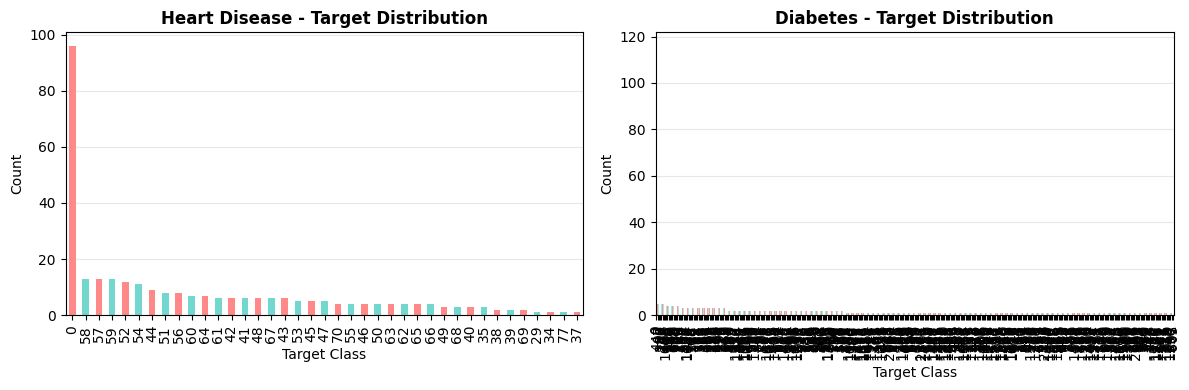

Heart class distribution: {0: 96, 58: 13, 57: 13, 59: 13, 52: 12, 54: 11, 44: 9, 51: 8, 56: 8, 60: 7, 64: 7, 61: 6, 42: 6, 41: 6, 48: 6, 67: 6, 43: 6, 53: 5, 45: 5, 47: 5, 70: 4, 55: 4, 46: 4, 50: 4, 63: 4, 62: 4, 65: 4, 66: 4, 49: 3, 68: 3, 40: 3, 35: 3, 38: 2, 39: 2, 69: 2, 29: 1, 34: 1, 77: 1, 37: 1}
Diabetes class distribution: {0: 116, 440: 5, 97: 5, 180: 5, 200: 5, 224: 5, 216: 5, 1008: 5, 95: 4, 396: 4, 198: 4, 109: 4, 480: 4, 333: 4, 128: 4, 680: 4, 750: 4, 100: 4, 119: 4, 240: 4, 244: 4, 89: 3, 580: 3, 234: 3, 1150: 3, 1680: 3, 474: 3, 735: 3, 168: 3, 798: 3, 584: 3, 79: 3, 107: 3, 184: 3, 71: 3, 576: 3, 390: 3, 88: 3, 360: 3, 384: 3, 136: 3, 87: 3, 684: 3, 292: 3, 111: 3, 258: 3, 380: 3, 288: 3, 297: 3, 630: 3, 348: 3, 90: 3, 519: 3, 210: 3, 112: 3, 143: 3, 960: 3, 528: 3, 394: 2, 830: 2, 103: 2, 585: 2, 545: 2, 552: 2, 1220: 2, 1518: 2, 444: 2, 540: 2, 931: 2, 742: 2, 1113: 2, 1050: 2, 1309: 2, 1064: 2, 220: 2, 495: 2, 695: 2, 516: 2, 339: 2, 1378: 2, 80: 2, 492: 2, 864: 2, 

In [6]:
# Visualize Data Distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heart target distribution
y_heart.value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
axes[0].set_title('Heart Disease - Target Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Target Class')
axes[0].grid(axis='y', alpha=0.3)

# Diabetes target distribution  
y_diabetes.value_counts().plot(kind='bar', ax=axes[1], color=['#95E1D3', '#F38181'], alpha=0.8)
axes[1].set_title('Diabetes - Target Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Target Class')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Heart class distribution: {y_heart.value_counts().to_dict()}")
print(f"Diabetes class distribution: {y_diabetes.value_counts().to_dict()}")

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load datasets
heart_df = pd.read_csv('heart.csv')
diabetes_df = pd.read_csv('diabetes.csv')

print("Heart Dataset Shape:", heart_df.shape)
print("Diabetes Dataset Shape:", diabetes_df.shape)

Heart Dataset Shape: (1025, 14)
Diabetes Dataset Shape: (768, 9)


# Simple Baseline Models with Feature Engineering
## ML Final Project - Medical Decision Support